# Paquetes

In [362]:
using PhysicalConstants
using PhysicalConstants.CODATA2022: ħ, m_e, c_0
using Unitful
using Plots
using CSV
using DataFrames
using Measures

# Funciones

In [350]:
function Kronig_Penney(E, ω, b, V₀; m_eff = 0.067, normalizado = false, compacto = false)
    
    a = ω + b
    
    # estas dos variables las añado para que el coseno de k₁ y k₂ no haga overflow
    mₑc² = ustrip(uconvert(u"eV", m_e*c_0^2))                 # en EV
    ħc = ustrip(uconvert(u"eV*nm", ħ*c_0))                    # en eV nm

    k₁ = @. sqrt(2 * m_eff * mₑc² * E) / ħc                   # en nm⁻¹
    k₂ = @. sqrt(Complex(2 * m_eff * mₑc² * (E - V₀))) / ħc   # en nm⁻¹
    
    # Valor de cos(ka), con esto vemos las bandas imponiendo que f este entre -1 y +1
    f = @. cos(k₁*ω)*cos(k₂*b) - ((k₁^2 + k₂^2) / (2 * k₁ * k₂)) * sin(k₁*ω)*sin(k₂*b)
    
    banda = real.(f)
    
    k_eff, E_eff = Calcular_k(E, banda, a, normalizado, compacto)
    
    return banda, k_eff, E_eff
end



function Calcular_k(E, band, a, normalizar, compactar)
    
    Es = []
    ks = []
    counter = -0.5 * !compactar
    
    for i in 2:length(band)
        if ((abs(band[i]) < 1.0) ⊻ (abs(band[i-1]) < 1.0))
            counter += 0.5 * !compactar
        end
        if (abs(band[i]) <= 1.0)
            push!(Es, E[i])
            if normalizar
                push!(ks, (1 - 2 * !es_par(counter)) * (acos(band[i])/π) + es_entero(counter) * (counter + !es_par(counter)))           # en unidades de π/a
            else
                push!(ks, (1 - 2 * !es_par(counter)) * (acos(band[i])/a) + es_entero(counter) * (counter + !es_par(counter) ) * π / a)  # k en nm⁻¹
            end
        end
    end
    
    return ks, Es
end

function es_par(x)
    return x % 2 == 0
end

function es_entero(x)
    return x % 1 == 0
end

function compute_v(E, k)
    v = zeros(length(E))
    eV_to_J = 1.602176634e-19
    nm_inv_to_m_inv = 1e9
    for i in 2:length(E)
        Δk = (k[i] - k[i-1]) * nm_inv_to_m_inv
        ΔE = (E[i] - E[i-1]) * eV_to_J
        v[i] = ΔE / Δk / ustrip(ħ)
        if v[i] > 1e7
            v[i] = NaN
        end
    end
    return v
end

function n_to_k_fit(n, N, a; normalizado = true)
    k = @. 2 / N * (0.5559 * n - 0.5674) * (π / a)^!normalizado
    return k 
end

#################################
# ESTO NO FUNCIONA BIEN TODAVIA #
#################################
function leer_archivo_csv(carpeta, archivo; usuario = "JRcodes73")
    ruta = joinpath(@__DIR__, "..", carpeta, archivo)
    ruta = normpath(ruta)
    # l_ruta = length(archivo)
    # posible_usuario = archivo[l_ruta-length(usuario):l_ruta-1]
    # if posible_usuario == usuario
    #     exit
    # end
    println(ruta)
    data = CSV.read(ruta, DataFrame, header = 4)
    return data
end

leer_archivo_csv (generic function with 1 method)

# Datos

In [352]:
Energy = 0:0.00005:1.0
Barrier_Potential = 0.3
Barrier_width = 15.0
Well_width = 3.0
banda, k_bandas, E_bandas = Kronig_Penney(Energy,Well_width,Barrier_width,Barrier_Potential, m_eff = 0.023, normalizado = false, compacto = false)

([NaN, 484.56062179190764, 484.2070067126348, 483.85360902140303, 483.5004286042905, 483.14746534742585, 482.7947191369908, 482.4421898592176, 482.08987740039163, 481.73778164684677  …  0.8868170999920696, 0.8870109570745383, 0.8872046597774099, 0.8873982080851023, 0.8875916019820626, 0.8877848414527633, 0.8879779264817074, 0.888170857053427, 0.8883636331524775, 0.8885562547634474], Any[0.005304425542118902, 0.009216525557104654, 0.011909840616852978, 0.014100972255410118, 0.015997634270938022, 0.017694789479845884, 0.019245307540525, 0.020682209693857218, 0.022027755684005314, 0.0232977933748224  …  0.6714436485996916, 0.6714669632433692, 0.6714902781084348, 0.6715135931976579, 0.6715369085138179, 0.6715602240597028, 0.6715835398381106, 0.6716068558518484, 0.6716301721037324, 0.671653488596589], Any[0.2134, 0.21345, 0.2135, 0.21355, 0.2136, 0.21365, 0.2137, 0.21375, 0.2138, 0.21385  …  0.99955, 0.9996, 0.99965, 0.9997, 0.99975, 0.9998, 0.99985, 0.9999, 0.99995, 1.0])

# Gráficos

In [368]:
p1 = plot(Energy, banda, ylims = [-2.0,2.0], legend = false, xlabel = "E (eV)", ylabel = "f(E)", size = (400,400), left_margin = 3mm, bottom_margin = 3mm, grid = false)
hline!([1.0, -1.0])
p2 = plot(k_bandas,E_bandas, legend = false, xlabel = "k (nm⁻¹)", ylabel = "E (eV)", size = (400,400), grid = false)

p_12 = plot(p1,p2, layout = (1,2), size = (800,400))
savefig(p_12, "graficas_banda")

"c:\\Users\\JRSucks73\\Documents\\GNOMOS\\JRcodes73\\Bandas_anal\\graficas_banda.png"

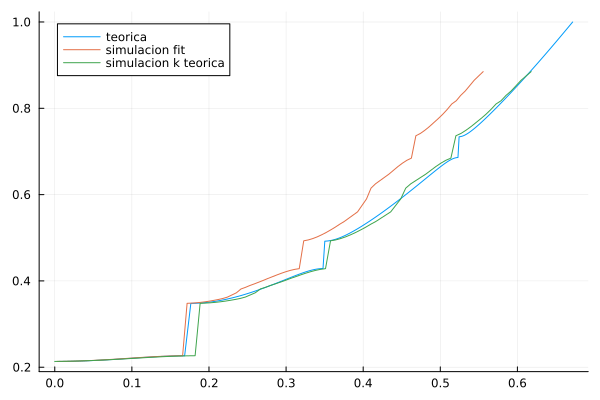

In [345]:
p2 = plot(k_bandas,E_bandas, label = "teorica")
plot!(p2, k_sim, prueba[:,2], label = "simulacion fit")
plot!(p2, k_sim_fit, prueba[:,2], label = "simulacion k teorica")

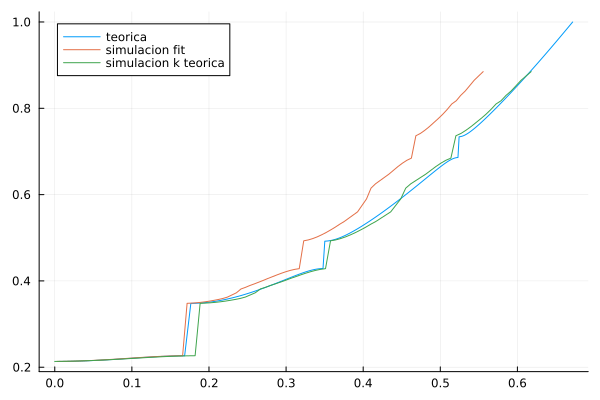

In [346]:
display(p2)

c:\Users\JRSucks73\Documents\GNOMOS\JRcodes73\Pruebas\100_pozos_juande_params.txt


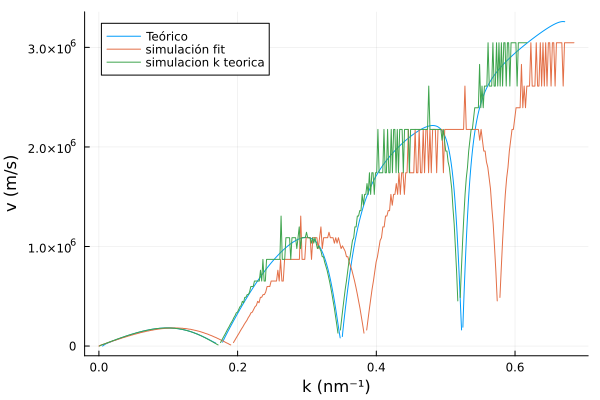

In [351]:
prueba = leer_archivo_csv("Pruebas", "100_pozos_juande_params.txt")
v_g = compute_v(E_bandas,k_bandas)
velocidad = plot(k_bandas,v_g, xlabel = "k (nm⁻¹)", ylabel = "v (m/s)", label = "Teórico")

ocurrencias = prueba.Occurrence
E_sim = prueba[:,2]
a = Barrier_width + Well_width
N = 100
k_sim_fit = n_to_k_fit(ocurrencias, N, a, normalizado = false)
k_sim = (prueba.Occurrence .- 0.5) ./ N .* π ./ a
v_sim = compute_v(E_sim, k_sim)
plot!(velocidad, k_sim_fit, v_sim, label = "simulación fit")
plot!(velocidad, k_sim, v_sim, label = "simulacion k teorica")


c:\Users\JRSucks73\Documents\GNOMOS\JRcodes73\Pruebas\30_pozos_juande_params.txt


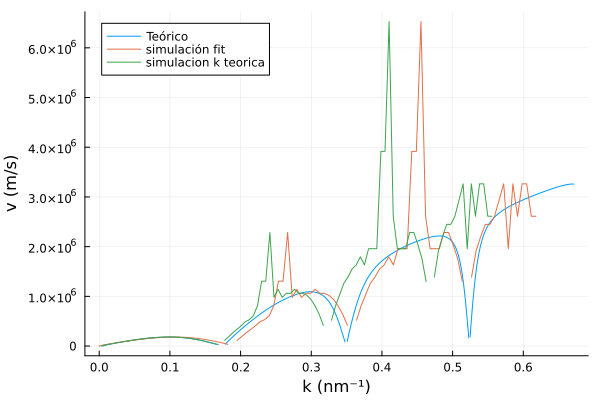

In [349]:
prueba = leer_archivo_csv("Pruebas", "30_pozos_juande_params.txt")
v_g = compute_v(E_bandas,k_bandas)
velocidad = plot(k_bandas,v_g, xlabel = "k (nm⁻¹)", ylabel = "v (m/s)", label = "Teórico")

ocurrencias = prueba.Occurrence
E_sim = prueba[:,2]
a = Barrier_width + Well_width
N = 30
k_sim_fit = n_to_k_fit(ocurrencias, N, a, normalizado = false)
k_sim = (prueba.Occurrence .- 0.5) ./ N .* π ./ a
v_sim = compute_v(E_sim, k_sim)
plot!(velocidad, k_sim_fit, v_sim, label = "simulación fit")
plot!(velocidad, k_sim, v_sim, label = "simulacion k teorica")
